In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, fbeta_score

# ============================================
# 1. Load Data & Drop Duplicates
# ============================================
df = pd.read_csv("census.csv")
print(" Original Shape:", df.shape)

df = df.drop_duplicates()
print(" After Duplicates:", df.shape)

# ============================================
# 2. Simplify Categorical Features
# ============================================
df['marital-status'] = df['marital-status'].str.strip()
married_categories   = ['Married-civ-spouse', 'Married-AF-spouse', 'Married-spouse-absent']
df['marital-status'] = df['marital-status'].apply(lambda x: 'Married' if x in married_categories else 'Single')

df['native-country'] = df['native-country'].str.strip()
df['native-country'] = df['native-country'].apply(lambda x: 'US' if x == 'United-States' else 'Non-US')

df['race'] = df['race'].str.strip()
df['race'] = df['race'].apply(lambda x: 'White' if x == 'White' else 'Non-White')

df['workclass'] = df['workclass'].str.strip()
df['workclass']  = df['workclass'].replace({
    'Self-emp-not-inc': 'Self-Employed',
    'Self-emp-inc'    : 'Self-Employed',
    'Federal-gov'     : 'Government',
    'State-gov'       : 'Government',
    'Local-gov'       : 'Government',
    'Without-pay'     : 'Other',
    'Never-worked'    : 'Other'
})

# ============================================
# 3. Feature Engineering (قبل الـ Log Transform)
# ============================================
df['capital_net'] = df['capital-gain'] - df['capital-loss']
df['has_capital'] = (df['capital_net'] > 0).astype(int)
df['overtime']    = (df['hours-per-week'] > 40).astype(int)

# ============================================
# 4. Log Transform
# ============================================
skewed = ['capital-gain', 'capital-loss']
df[skewed] = df[skewed].apply(lambda x: np.log(x + 1))

# ============================================
# 5. Split Features & Target (بدون Encoding)
# ============================================
y = df['income'].map({'<=50K': 0, '>50K': 1})
X = df.drop('income', axis=1)

# ============================================
# 6. Train/Test Split (تقسيم الداتا وهي لسه خام نسبياً)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(" Training set:", X_train.shape)
print(" Testing set :", X_test.shape)

# ============================================
# 7. 🛠️ Professional Encoding & Scaling 🛠️
# ============================================
# تحديد أنواع العواميد
numerical_cols   = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net']
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
binary_cols      = ['has_capital', 'overtime']

# أ. Scaling للعواميد الرقمية
scaler = MinMaxScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[numerical_cols]), columns=numerical_cols, index=X_train.index)
X_test_num  = pd.DataFrame(scaler.transform(X_test[numerical_cols]), columns=numerical_cols, index=X_test.index)

# ب. One-Hot Encoding للعواميد النصية (مع تجاهل أي فئة جديدة تظهر في الـ Test)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = pd.DataFrame(encoder.fit_transform(X_train[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)
X_test_cat  = pd.DataFrame(encoder.transform(X_test[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)

# ج. العواميد الـ Binary الجاهزة
X_train_bin = X_train[binary_cols]
X_test_bin  = X_test[binary_cols]

# د. تجميع كل العواميد تاني في داتا فريم واحدة نهائية
X_train_final = pd.concat([X_train_num, X_train_cat, X_train_bin], axis=1)
X_test_final  = pd.concat([X_test_num, X_test_cat, X_test_bin], axis=1)

print(" Total features after transformations:", X_train_final.shape[1])

# ============================================
# 8. Model Training (XGBoost)
# ============================================
print(" Training Model...")
clf = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 7,
    learning_rate    = 0.01,
    subsample        = 1.0,
    colsample_bytree = 1.0,
    gamma            = 0.01,
    min_child_weight = 1,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)

clf.fit(X_train_final, y_train)

# ============================================
# 9. Evaluation (Threshold = 0.60)
# ============================================
y_proba = clf.predict_proba(X_test_final)[:, 1]
y_pred_final = (y_proba >= 0.60).astype(int)

print(" Final Classification Report (Threshold=0.60):")
print(classification_report(y_test, y_pred_final))

print(" Accuracy  : {:.4f}".format(accuracy_score(y_test, y_pred_final)))
print(" Precision : {:.4f}".format(precision_score(y_test, y_pred_final)))
print(" Recall    : {:.4f}".format(recall_score(y_test, y_pred_final)))
print(" F1 Class1 : {:.4f}".format(f1_score(y_test, y_pred_final)))
print(" F0.5-score: {:.4f}".format(fbeta_score(y_test, y_pred_final, beta=0.5)))

📊 Original Shape: (45222, 14)
📊 After Duplicates: (39240, 14)

🚀 Training set: (31392, 16)
🚀 Testing set : (7848, 16)

✅ Total features after transformations: 56

⚙️ Training Model...

📊 Final Classification Report (Threshold=0.60):
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      5853
           1       0.87      0.52      0.65      1995

    accuracy                           0.86      7848
   macro avg       0.86      0.75      0.78      7848
weighted avg       0.86      0.86      0.84      7848

✅ Accuracy  : 0.8578
✅ Precision : 0.8709
✅ Recall    : 0.5173
✅ F1 Class1 : 0.6491
✅ F0.5-score: 0.7661


⏳ جاري استخراج أهمية الخصائص من الموديل...

🏆 أعلى 15 خصائص تأثيراً:
----------------------------------------
                          Feature  Importance
0          marital-status_Married    0.639863
1                    capital-gain    0.054757
2                   education-num    0.053444
3       occupation_ Other-service    0.024676
4                    capital-loss    0.021319
5   occupation_ Handlers-cleaners    0.014484
6         relationship_ Own-child    0.014203
7     occupation_ Farming-fishing    0.013255
8     occupation_ Exec-managerial    0.012845
9                             age    0.010493
10       occupation_ Tech-support    0.010413
11                 hours-per-week    0.010144
12     occupation_ Prof-specialty    0.009824
13   relationship_ Other-relative    0.009634
14             relationship_ Wife    0.008285
----------------------------------------


C:\Users\almnara\AppData\Local\Temp\ipykernel_21712\326346628.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(top_n), palette='viridis')


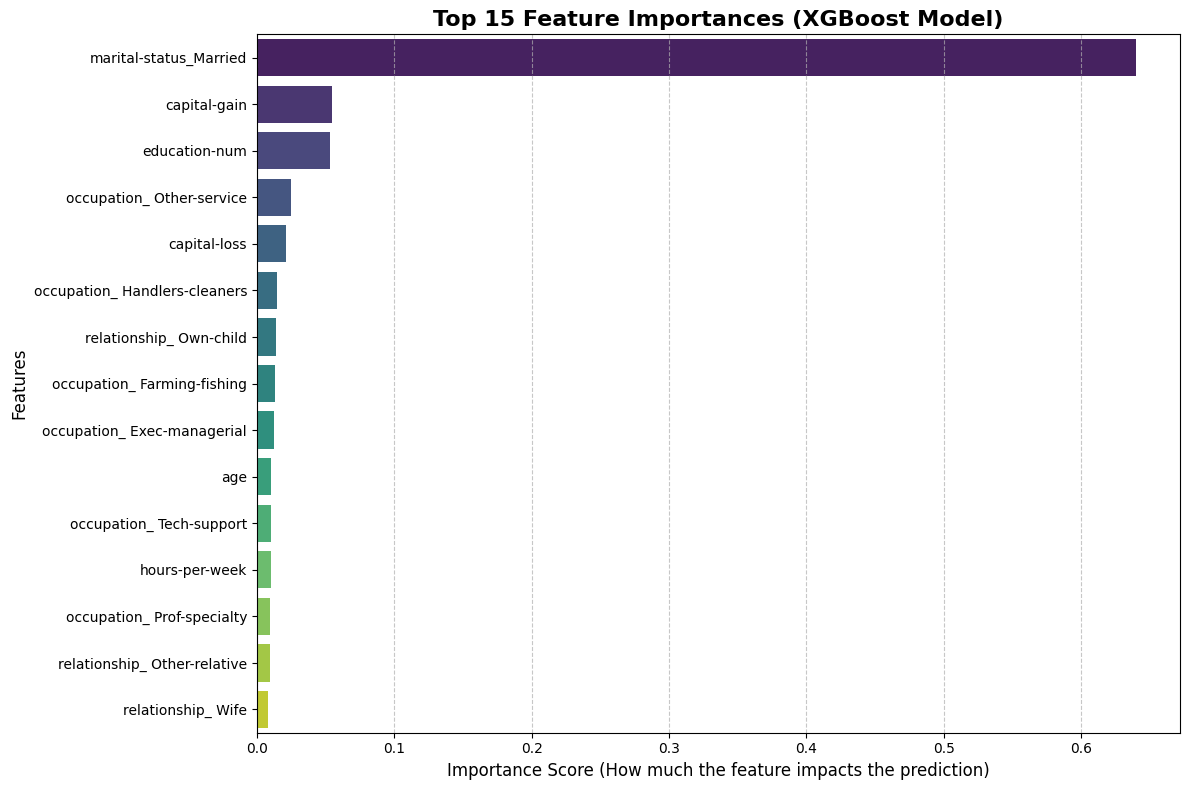

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 🔍 استخراج ورسم أهمية الخصائص (Feature Importance)
# ============================================

print("⏳ جاري استخراج أهمية الخصائص من الموديل...")

# 1. استخراج الأهمية من الموديل اللي دربناه (clf)
importances = clf.feature_importances_

# 2. الحصول على أسماء العواميد من داتا التدريب النهائية
feature_names = X_train_final.columns

# 3. تجميعهم في جدول وترتيبهم من الأهم للأقل أهمية
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. طباعة أعلى 15 خاصية كأرقام
top_n = 15
print(f"\n🏆 أعلى {top_n} خصائص تأثيراً:")
print("-" * 40)
print(importance_df.head(top_n).to_string())
print("-" * 40)

# 5. رسم بياني شيك جداً للنتيجة
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(top_n), palette='viridis')

# تظبيط شكل الرسمة
plt.title(f'Top {top_n} Feature Importances (XGBoost Model)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (How much the feature impacts the prediction)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# عرض الرسمة جوه النوت بوك
plt.show()